In [39]:
import pandas as pd
import numpy as np
from bert_score import BERTScorer
import os
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
#from transformers import AutoModel, AutoTokenizer

#model_name = "allenai/longformer-base-4096"
#save_directory = "./local_longformer"

# Download and save
#tokenizer = AutoTokenizer.from_pretrained(model_name)
#model = AutoModel.from_pretrained(model_name)

#tokenizer.save_pretrained(save_directory)
#model.save_pretrained(save_directory)

In [ ]:
#local_path = os.path.abspath("PATH\\TO\\LONGFORMER\\HERE")

In [ ]:
VBReE_results_df = pd.read_csv("v-bree_mmlupro_validation_20260228.csv")
validation_data_df = pd.read_csv("validation-00000-of-00001.csv")

In [5]:
VBReE_results_df.head()

,Unnamed: 0,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,selected_choice,response_tokens,scoring_model,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score
0,0,0,0,openai/gpt-oss-20b:groq,The symmetric group $S_n$ has $\n\factorial{n}...,"['0', '30', '3', '10', '12', '50', '2', '100',...",math,397,NaN,The ring (2mathbb{Z}) consists of all even int...,A,975,Qwen/Qwen2.5-7B-Instruct:together,85.0,NaN,NaN,False,NaN
1,1,0,1,Qwen/Qwen2.5-7B-Instruct:together,The symmetric group $S_n$ has $\n\factorial{n}...,"['0', '30', '3', '10', '12', '50', '2', '100',...",math,409,The ring (2mathbb{Z}) consists of all even int...,The ring 2Z consists of all even integers. As ...,A,131,meta-llama/Llama-3.1-8B-Instruct:cerebras,0.0,NaN,NaN,False,NaN
2,2,0,2,meta-llama/Llama-3.1-8B-Instruct:cerebras,The symmetric group $S_n$ has $\n\factorial{n}...,"['0', '30', '3', '10', '12', '50', '2', '100',...",math,506,The ring 2Z consists of all even integers. As ...,The characteristic of the ring 2Z is 0.,A,32,openai/gpt-oss-20b:groq,95.0,60.000000,2725.000000,False,0.012605
3,3,0,3,openai/gpt-oss-20b:groq,The symmetric group $S_n$ has $\n\factorial{n}...,"['0', '30', '3', '10', '12', '50', '2', '100',...",math,408,The characteristic of the ring 2Z is 0.,The characteristic of a ring (R) is the smalle...,A,411,Qwen/Qwen2.5-7B-Instruct:together,85.0,60.000000,2725.000000,False,0.010929
4,4,0,4,Qwen/Qwen2.5-7B-Instruct:together,The symmetric group $S_n$ has $\n\factorial{n}...,"['0', '30', '3', '10', '12', '50', '2', '100',...",math,440,The characteristic of a ring (R) is the smalle...,The characteristic of the ring $2\textbf{Z}$ i...,A,130,meta-llama/Llama-3.1-8B-Instruct:cerebras,100.0,93.333333,58.333333,False,0.680749


In [6]:
first_answers = VBReE_results_df[VBReE_results_df["iteration"] == 0]
selected_answers = VBReE_results_df[VBReE_results_df["chosen_response"] == True]
starter = first_answers["updated_answer"].tolist()
submitted = selected_answers["updated_answer"].tolist()
gold_standard = validation_data_df["cot_content"].tolist()

In [7]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

CUDA available: True
GPU Device: NVIDIA GeForce RTX 4060
CUDA Version: 13.0


In [8]:
scorer = BERTScorer(model_type='roberta-base', lang='en', device='cuda')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
P_internal, R_internal, F1_internal = scorer.score(starter, submitted)
P_start, R_start, F1_start = scorer.score(starter, gold_standard)
P_submit, R_submit, F1_submit = scorer.score(submitted, gold_standard)

In [10]:
print(f"Internal F1 = {F1_internal.mean():.4f}\nStart-to-truth F1 = {F1_start.mean():.4f}\nSubmitted-to-truth F1 = {F1_submit.mean():.4f}\n"+
      f"Internal P = {P_internal.mean():.4f}\nStart-to-truth P = {P_start.mean():.4f}\nSubmitted-to-truth P = {P_submit.mean():.4f}\n"+
      f"Internal R = {R_internal.mean():.4f}\nStart-to-truth R = {R_start.mean():.4f}\nSubmitted-to-truth R = {R_submit.mean():.4f}")

Internal F1 = 0.8841
Start-to-truth F1 = 0.8526
Submitted-to-truth F1 = 0.8631
Internal P = 0.8920
Start-to-truth P = 0.8696
Submitted-to-truth P = 0.8748
Internal R = 0.8789
Start-to-truth R = 0.8374
Submitted-to-truth R = 0.8526


In [12]:
f_F1, p_F1 = stats.f_oneway(F1_start, F1_submit)
print(f"F-score of differences: {f_F1}\np-value of diffences: {p_F1}")

F-score of differences: 2.901543562162793
p-value of diffences: 0.09074575327561463


In [13]:
f_P, p_P = stats.f_oneway(P_start, P_submit)
print(f"F-score of differences: {f_P}\np-value of diffences: {p_P}")

F-score of differences: 0.5359432960964955
p-value of diffences: 0.46536030895768576


In [14]:
f_R, p_R = stats.f_oneway(R_start, R_submit)
print(f"F-score of differences: {f_R}\np-value of diffences: {p_R}")

F-score of differences: 4.58477373331228
p-value of diffences: 0.03401415409216296


In [15]:
wrong_to_right = 0
right_to_wrong = 0
wrong_to_wrong = 0

for i in range(len(first_answers)):
    if selected_answers.iloc[i]['selected_choice'] == validation_data_df.iloc[i]['answer'] and first_answers.iloc[i]['selected_choice'] != validation_data_df.iloc[i]['answer']:
        wrong_to_right += 1
    elif selected_answers.iloc[i]['selected_choice'] != validation_data_df.iloc[i]['answer'] and first_answers.iloc[i]['selected_choice'] == validation_data_df.iloc[i]['answer']:
        right_to_wrong += 1
    elif selected_answers.iloc[i]['selected_choice'] == first_answers.iloc[i]['selected_choice'] and first_answers.iloc[i]['selected_choice'] != validation_data_df.iloc[i]['answer']:
        wrong_to_wrong +=1

In [16]:
print(f"wrong-to-right rate: {wrong_to_right/70}\nright-to-wrong rate: {right_to_wrong/70}\nwrong-to-wrong rate: {wrong_to_wrong/70}")

wrong-to-right rate: 0.2571428571428571
right-to-wrong rate: 0.0
wrong-to-wrong rate: 0.15714285714285714


In [17]:
selected_answers["iteration"].mean()

10.1

In [18]:
first_answers['model'].value_counts()/70

model
openai/gpt-oss-20b:groq                      0.457143
meta-llama/Llama-3.1-8B-Instruct:cerebras    0.357143
Qwen/Qwen2.5-7B-Instruct:together            0.185714
Name: count, dtype: float64

In [19]:
selected_answers['model'].value_counts()/70

model
Qwen/Qwen2.5-7B-Instruct:together            0.457143
meta-llama/Llama-3.1-8B-Instruct:cerebras    0.342857
openai/gpt-oss-20b:groq                      0.200000
Name: count, dtype: float64

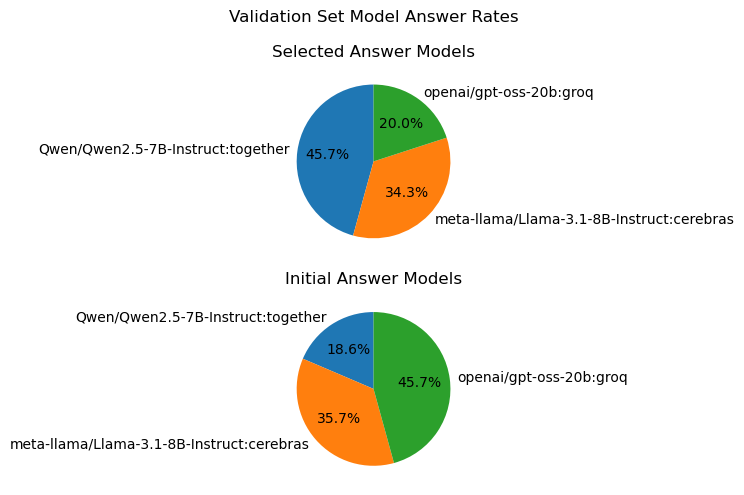

In [93]:
selected_model = selected_answers['model'].value_counts()/len(selected_answers)
first_model = first_answers['model'].value_counts()/len(selected_answers)

models = pd.concat([selected_model, first_model], axis=1)
models.columns=["selected_model", "initial_model"]
#print(models)

sizes1 = models["selected_model"].values
sizes2 = models["initial_model"].values
labels = models.index

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

# 2. Plot the first pie chart
ax1.pie(sizes1, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.set_title('Selected Answer Models')

# 3. Plot the second pie chart
ax2.pie(sizes2, labels=labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Initial Answer Models')

plt.suptitle("Validation Set Model Answer Rates")

# Display the charts
plt.tight_layout()
plt.show()

(0.0, 100.0)

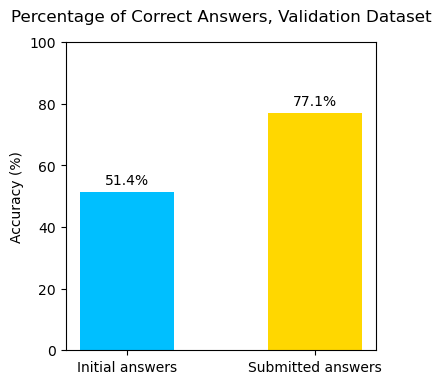

In [88]:
val_percent_correct_submitted = len(selected_answers[selected_answers['selected_choice'] == validation_data_df['answer'].values]) / len(selected_answers) * 100
val_percent_correct_first = len(first_answers[first_answers['selected_choice'] == validation_data_df['answer'].values]) / len(first_answers) * 100


labels = ['Initial answers', 'Submitted answers']
values = [val_percent_correct_first, val_percent_correct_submitted]

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(labels, values, color=["deepskyblue", "gold"], width=0.5)

# This one line adds the labels automatically
ax.bar_label(bars, padding=3, fmt="%.1f%%")
ax.set_title("Percentage of Correct Answers, Validation Dataset", pad=15)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)


In [ ]:
VBReE_test_results_df = pd.read_csv("v-bree_mmlupro_test_0_3000_20260306_final.csv")
VBReE_extended_test_results_df = pd.read_csv("vbree_mmlupro_var_thresh_testing_20260401.csv")

In [125]:
print(f"V-BReE extended test mean iterations to answer submission: {VBReE_extended_test_results_df[VBReE_extended_test_results_df["chosen_response"] == True]["iteration"].mean():.2f}")

V-BReE extended test mean iterations to answer submission: 32.31


In [ ]:
mask = (VBReE_test_results_df['iteration'] != 0) & VBReE_test_results_df['updated_answer'].notna() & VBReE_test_results_df['previous_answer'].notna()
indices = VBReE_test_results_df[mask].index

VBReE_test_results_df['bert_f1'] = 0.0

chunk_size = 2000 

for i in range(0, len(indices), chunk_size):
    chunk_indices = indices[i : i + chunk_size]
    
    cands = VBReE_test_results_df.loc[chunk_indices, 'updated_answer'].astype(str).tolist()
    refs = VBReE_test_results_df.loc[chunk_indices, 'previous_answer'].astype(str).tolist()
    
    # batch_size=16 works best with the tested GPU
    _, _, F1 = scorer.score(cands, refs, batch_size=16)
    
    VBReE_test_results_df.loc[chunk_indices, 'bert_f1'] = F1.cpu().numpy()
    
    print(f"Processed {i + len(chunk_indices)} / {len(indices)}")

Processed 2000 / 54666
Processed 4000 / 54666
Processed 6000 / 54666
Processed 8000 / 54666
Processed 10000 / 54666
Processed 12000 / 54666
Processed 14000 / 54666
Processed 16000 / 54666
Processed 18000 / 54666
Processed 20000 / 54666
Processed 22000 / 54666
Processed 24000 / 54666
Processed 26000 / 54666
Processed 28000 / 54666
Processed 30000 / 54666
Processed 32000 / 54666
Processed 34000 / 54666
Processed 36000 / 54666
Processed 38000 / 54666
Processed 40000 / 54666
Processed 42000 / 54666
Processed 44000 / 54666
Processed 46000 / 54666
Processed 48000 / 54666
Processed 50000 / 54666
Processed 52000 / 54666
Processed 54000 / 54666
Processed 54666 / 54666


In [22]:
scored_df = VBReE_test_results_df[VBReE_test_results_df['bert_f1'] > 0]

# 2. Group and calculate mean, count, and standard deviation
performance_stats = scored_df.groupby('model')['bert_f1'].agg(['mean', 'count', 'std'])

# 3. Sort by the highest mean score
performance_stats = performance_stats.sort_values(by='mean', ascending=False)

print("Aggregate Model BERT F1 Performance Stats, Original Test\n")
print(performance_stats)

Aggregate Model BERT F1 Performance Stats, Original Test

                                               mean  count       std
model                                                               
meta-llama/Llama-3.1-8B-Instruct:cerebras  0.945354  18246  0.067705
Qwen/Qwen2.5-7B-Instruct:together          0.926264  18154  0.090073
openai/gpt-oss-20b:groq                    0.895286  18266  0.083832


In [ ]:
mask = (VBReE_extended_test_results_df['iteration'] != 0) & VBReE_extended_test_results_df['updated_answer'].notna() & VBReE_extended_test_results_df['previous_answer'].notna()
indices = VBReE_extended_test_results_df[mask].index

VBReE_extended_test_results_df['bert_f1'] = 0.0

chunk_size = 2000 

for i in range(0, len(indices), chunk_size):
    chunk_indices = indices[i : i + chunk_size]
    
    cands = VBReE_extended_test_results_df.loc[chunk_indices, 'updated_answer'].astype(str).tolist()
    refs = VBReE_extended_test_results_df.loc[chunk_indices, 'previous_answer'].astype(str).tolist()
    
    _, _, F1 = scorer.score(cands, refs, batch_size=16)
    
    VBReE_extended_test_results_df.loc[chunk_indices, 'bert_f1'] = F1.cpu().numpy()
    
    print(f"Processed {i + len(chunk_indices)} / {len(indices)}")

Processed 2000 / 30364
Processed 4000 / 30364
Processed 6000 / 30364
Processed 8000 / 30364
Processed 10000 / 30364
Processed 12000 / 30364
Processed 14000 / 30364
Processed 16000 / 30364
Processed 18000 / 30364
Processed 20000 / 30364
Processed 22000 / 30364
Processed 24000 / 30364
Processed 26000 / 30364
Processed 28000 / 30364
Processed 30000 / 30364
Processed 30364 / 30364


In [ ]:
extended_scored_df = VBReE_extended_test_results_df[VBReE_extended_test_results_df['bert_f1'] > 0]

extended_performance_stats = extended_scored_df.groupby('model')['bert_f1'].agg(['mean', 'count', 'std'])

extended_performance_stats = extended_performance_stats.sort_values(by='mean', ascending=False)

print("Aggregate Model BERT F1 Performance Stats, Extended Variance Test\n")
print(extended_performance_stats)

Aggregate Model BERT F1 Performance Stats, Extended Variance Test

                                               mean  count       std
model                                                               
meta-llama/Llama-3.1-8B-Instruct:cerebras  0.961013  10109  0.051143
Qwen/Qwen2.5-7B-Instruct:together          0.948328  10114  0.061121
openai/gpt-oss-20b:groq                    0.921952  10141  0.061165


In [25]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Filter for rows that were actually scored (avoiding the 0.0 placeholders)
VBReE_test_scored = VBReE_test_results_df[VBReE_test_results_df['bert_f1'] > 0].copy()
VBReE_extended_scored = VBReE_extended_test_results_df[VBReE_extended_test_results_df['bert_f1'] > 0].copy()

# Label the sources
VBReE_test_scored['source'] = 'v1'
VBReE_extended_scored['source'] = 'v2'

# Combine them
combined_df = pd.concat([VBReE_test_scored, VBReE_extended_scored])

model = ols('bert_f1 ~ C(model) + C(source) + C(model):C(source)', data=combined_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                        sum_sq       df            F        PR(>F)
C(model)             30.958193      2.0  2852.218774  0.000000e+00
C(source)             8.995900      1.0  1657.608083  0.000000e+00
C(model):C(source)    0.398048      2.0    36.672680  1.202605e-16
Residual            461.428385  85024.0          NaN           NaN


In [138]:
test_grouped_corr = VBReE_test_scored.groupby('model')[['confidence_score', 'bert_f1']].apply(
    lambda x: x['confidence_score'].corr(x['bert_f1'])
)

# For the Extended Test Set
extended_grouped_corr = VBReE_extended_scored.groupby('model')[['confidence_score', 'bert_f1']].apply(
    lambda x: x['confidence_score'].corr(x['bert_f1'])
)

# Combine for comparison
comparison_df = pd.DataFrame({
    'Original_Corr': test_grouped_corr,
    'Extended_Corr': extended_grouped_corr
})

print(comparison_df)

# FISHER Z-TRANSFORMATION
comparison_df['Original_Z'] = np.arctanh(comparison_df['Original_Corr'])
comparison_df['Extended_Z'] = np.arctanh(comparison_df['Extended_Corr'])

t_stat, p_val = stats.ttest_rel(comparison_df['Original_Z'], comparison_df['Extended_Z'])

print(f"\nP-value: {p_val:.4f}")

                                           Original_Corr  Extended_Corr
model                                                                  
Qwen/Qwen2.5-7B-Instruct:together               0.003932       0.062733
meta-llama/Llama-3.1-8B-Instruct:cerebras       0.004087      -0.008320
openai/gpt-oss-20b:groq                        -0.005201      -0.002515

P-value: 0.5288


In [ ]:
test_grouped_corr = VBReE_test_scored.groupby('model')[['iteration', 'bert_f1']].apply(
    lambda x: x['iteration'].corr(x['bert_f1'])
)

# For the Extended Test Set
extended_grouped_corr = VBReE_extended_scored.groupby('model')[['iteration', 'bert_f1']].apply(
    lambda x: x['iteration'].corr(x['bert_f1'])
)

# Combine for comparison
comparison_df = pd.DataFrame({
    'Original_Corr': test_grouped_corr,
    'Extended_Corr': extended_grouped_corr
})

print(comparison_df)

comparison_df['Original_Z'] = np.arctanh(comparison_df['Original_Corr'])
comparison_df['Extended_Z'] = np.arctanh(comparison_df['Extended_Corr'])

t_stat, p_val = stats.ttest_rel(comparison_df['Original_Z'], comparison_df['Extended_Z'])

print(f"\nP-value: {p_val:.4f}")

                                           Original_Corr  Extended_Corr
model                                                                  
Qwen/Qwen2.5-7B-Instruct:together              -0.025258       0.024689
meta-llama/Llama-3.1-8B-Instruct:cerebras       0.033977       0.052617
openai/gpt-oss-20b:groq                         0.034747       0.090118

P-value: 0.0690


In [141]:
print("11 or More Iterations:\n")

test_grouped_corr = (
    VBReE_test_scored.loc[VBReE_test_scored['iteration'] > 10]
    .groupby('model')[['iteration', 'bert_f1']]  # Explicitly select columns here
    .apply(lambda x: x['iteration'].corr(x['bert_f1']), include_groups=False)
)

extended_grouped_corr = (
    VBReE_extended_scored.loc[VBReE_extended_scored['iteration'] > 10]
    .groupby('model')[['iteration', 'bert_f1']]  # Explicitly select columns here
    .apply(lambda x: x['iteration'].corr(x['bert_f1']), include_groups=False)
)

comparison_df = pd.DataFrame({
    'Original_Corr': test_grouped_corr,
    'Extended_Corr': extended_grouped_corr
})

print(comparison_df)

comparison_df['Original_Z'] = np.arctanh(comparison_df['Original_Corr'])
comparison_df['Extended_Z'] = np.arctanh(comparison_df['Extended_Corr'])

t_stat, p_val = stats.ttest_rel(comparison_df['Original_Z'], comparison_df['Extended_Z'])

print(f"\nP-value: {p_val:.4f}")

print("\n10 or Fewer Iterations:\n")

test_grouped_corr = (
    VBReE_test_scored.loc[VBReE_test_scored['iteration'] < 11]
    .groupby('model')[['iteration', 'bert_f1']]  # Explicitly select columns here
    .apply(lambda x: x['iteration'].corr(x['bert_f1']), include_groups=False)
)

extended_grouped_corr = (
    VBReE_extended_scored.loc[VBReE_extended_scored['iteration'] < 11]
    .groupby('model')[['iteration', 'bert_f1']]  # Explicitly select columns here
    .apply(lambda x: x['iteration'].corr(x['bert_f1']), include_groups=False)
)
comparison_df = pd.DataFrame({
    'Original_Corr': test_grouped_corr,
    'Extended_Corr': extended_grouped_corr
})

print(comparison_df)

comparison_df['Original_Z'] = np.arctanh(comparison_df['Original_Corr'])
comparison_df['Extended_Z'] = np.arctanh(comparison_df['Extended_Corr'])

t_stat, p_val = stats.ttest_rel(comparison_df['Original_Z'], comparison_df['Extended_Z'])

print(f"\nP-value: {p_val:.4f}")

11 or More Iterations:

                                           Original_Corr  Extended_Corr
model                                                                  
Qwen/Qwen2.5-7B-Instruct:together              -0.081571       0.007028
meta-llama/Llama-3.1-8B-Instruct:cerebras      -0.003700       0.030062
openai/gpt-oss-20b:groq                        -0.068871       0.041005

P-value: 0.0762

10 or Fewer Iterations:

                                           Original_Corr  Extended_Corr
model                                                                  
Qwen/Qwen2.5-7B-Instruct:together               0.045871       0.064587
meta-llama/Llama-3.1-8B-Instruct:cerebras       0.037274       0.053239
openai/gpt-oss-20b:groq                         0.133268       0.161577

P-value: 0.0326


In [ ]:
test_grouped_corr = VBReE_test_scored.groupby('model')[['score_moving_variance', 'bert_f1']].apply(
    lambda x: x['score_moving_variance'].corr(x['bert_f1'])
)

# For the Extended Test Set
extended_grouped_corr = VBReE_extended_scored.groupby('model')[['score_moving_variance', 'bert_f1']].apply(
    lambda x: x['score_moving_variance'].corr(x['bert_f1'])
)

# Combine for comparison
comparison_df = pd.DataFrame({
    'Original_Corr': test_grouped_corr,
    'Extended_Corr': extended_grouped_corr
})

print(comparison_df)

comparison_df['Original_Z'] = np.arctanh(comparison_df['Original_Corr'])
comparison_df['Extended_Z'] = np.arctanh(comparison_df['Extended_Corr'])

t_stat, p_val = stats.ttest_rel(comparison_df['Original_Z'], comparison_df['Extended_Z'])

print(f"\nP-value: {p_val:.4f}")

                                           Original_Corr  Extended_Corr
model                                                                  
Qwen/Qwen2.5-7B-Instruct:together              -0.007942       0.030789
meta-llama/Llama-3.1-8B-Instruct:cerebras       0.003123       0.027373
openai/gpt-oss-20b:groq                        -0.002531       0.045115

P-value: 0.0326


In [133]:
test_grouped_corr = VBReE_test_scored.groupby('model')[['score_moving_variance', 'iteration']].apply(
    lambda x: x['score_moving_variance'].corr(x['iteration'])
)

# For the Extended Test Set
extended_grouped_corr = VBReE_extended_scored.groupby('model')[['score_moving_variance', 'iteration']].apply(
    lambda x: x['score_moving_variance'].corr(x['iteration'])
)

# Combine for comparison
comparison_df = pd.DataFrame({
    'Original_Corr': test_grouped_corr,
    'Extended_Corr': extended_grouped_corr
})

print(comparison_df)

comparison_df['Original_Z'] = np.arctanh(comparison_df['Original_Corr'])
comparison_df['Extended_Z'] = np.arctanh(comparison_df['Extended_Corr'])

t_stat, p_val = stats.ttest_rel(comparison_df['Original_Z'], comparison_df['Extended_Z'])

print(f"\nP-value: {p_val:.6f}")

                                           Original_Corr  Extended_Corr
model                                                                  
Qwen/Qwen2.5-7B-Instruct:together              -0.010229       0.019691
meta-llama/Llama-3.1-8B-Instruct:cerebras      -0.009282       0.020976
openai/gpt-oss-20b:groq                        -0.008527       0.022371

P-value: 0.000089


In [145]:
test_corr = VBReE_test_scored["iteration"].corr(VBReE_extended_scored["bert_f1"])
extended_corr = VBReE_extended_scored["iteration"].corr(VBReE_extended_scored["bert_f1"])


print(f"Test F1/iteration correlation: {test_corr:.6f}\nExtended F1/iteration correlation: {extended_corr:.6f}")

Test F1/iteration correlation: 0.000690
Extended F1/iteration correlation: 0.054113
